In [185]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

# --- НАСТРОЙКИ ПУТЕЙ ---
root_path = 'C:/GIT_REPOS/SCT/COSY/src/dat/'
src_path = 'C:/GIT_REPOS/SCT/COSY/src/'
lattice_name = 'electrostatic_maps'  # Имя файла без расширения

print("✅ Окружение настроено")

✅ Окружение настроено


In [186]:
class LatticeSlot:
    def __init__(self, element_type_name, element_id, s_start, library):
        self.type_name = element_type_name  # Имя ключа в библиотеке (напр. "EQ")
        self.id = element_id                # Порядковый номер (1, 2, 3...)
        self.s = s_start                    # ГДЕ стоит (координата S)
        
        # Ссылка на физику из библиотеки
        self.phys = library[element_type_name] 
        
        # Оптика в этой КОНКРЕТНОЙ точке (характеристика решетки)
        self.betx = 0.0
        self.bety = 0.0
        self.dispx = 0.0
        self.dispy = 0.0
        
class Quadrupole:
    def __init__(self, cmd, p, name):
        self.entity = "Quadrupole"
        self.name, self.type = name, cmd # Добавили type
        mapping = {
            'QUAD': {'L': 0, 'tilt': 1, 'K1': 2},
            'MQ':   {'L': 0, 'Bpt': 1, 'A': 2}
        }
        m = mapping.get(cmd, mapping['MQ'])
        self.L = float(p[m['L']])
        # Сохраняем и K1, и Bpt для универсальности
        self.K1 = float(p[m['K1']]) if cmd == 'QUAD' else None
        self.Bpt = float(p[m['Bpt']]) if cmd == 'MQ' else None

class Dipole:
    def __init__(self, cmd, p, name):
        self.entity = "Dipole"
        self.name, self.type = name, cmd
        if cmd == 'SBEND':
            self.L, self.angle = float(p[0]), float(p[1])
        else: # DI
            radius, self.angle = float(p[0]), float(p[1])
            self.L = abs(radius * self.angle)

class ElectrostaticDeflector:
    def __init__(self, cmd, p, name):
        self.entity = "ElectrostaticDeflector"
        self.name, self.type = name, cmd
        if cmd == 'ED':
            self.L, self.E_kVcm = float(p[0]), float(p[1])
        else: # ECL
            r, a = float(p[0]), float(p[1])
            self.L = abs(r * a * np.pi / 180.0)

class ElectrostaticQuadrupole:
    """Сущность: Электростатический квадруполь. Понимает формат EQ."""
    def __init__(self, cmd, p, name):
        self.entity = "ElectrostaticQuadrupole"
        self.name, self.type = name, cmd
        # EQ <length> <voltage at pole tip> <aperture>
        self.L = float(p[0])
        self.Vpt = float(p[1]) # Voltage at pole tip
        self.A = float(p[2])   # Aperture

class Drift:
    def __init__(self, cmd, p, name):
        self.entity = "Drift"
        self.name, self.type = name, cmd # Добавили type
        self.L = float(p[0]) if p else 0.0

class Sextupole:
    def __init__(self, cmd, p, name):
        self.entity = "Sextupole"
        self.name, self.type = name, cmd
        self.L = float(p[0])


class WienFilter:
    def __init__(self, cmd, p, name):
        self.entity, self.name, self.type = "WienFilter", name, cmd
        if cmd == 'WIEN':
            self.L, self.B_kGs, self.E_kVcm = float(p[0]), float(p[1]), float(p[2])
        else:
            self.L = float(p[2])

ENTITY_FACTORY = {
    'QUAD': Quadrupole, 'MQ': Quadrupole, 'SBEND': Dipole, 'DI': Dipole,
    'ED': ElectrostaticDeflector, 'ECL': ElectrostaticDeflector,
    'WIEN': WienFilter, 'WF': WienFilter, 'DL': Drift, 'MH': Sextupole, 'SEXT': Sextupole,
    'EQ': ElectrostaticQuadrupole
}

In [187]:
def get_lattice_variables(lattice_name, src_path, global_params):
    file_path = os.path.join(src_path, f"{lattice_name}.fox")
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Создаем пространство имен с глобальными параметрами
    # (EB1, SEXTGx1, SEXTGx2, SEXTGy1, SEXTGy2)
    vars_map = global_params.copy()
    
    # 1. Сначала ищем простые присваивания во всем файле
    simple_assigns = re.findall(r'(\w+)\s*:=\s*([^;]+);', content)
    
    # 2. Ищем блок вычислений внутри PROCEDURE (между LATTICE и BEGIN PERIOD)
    # Ищем строки типа Lf:=(-6.1863*A*A*1E+4)*1/2;
    calc_block = re.findall(r'(\w+)\s*:=\s*([^;]+);', content)

    for var, expr in calc_block:
        try:
            # Очищаем формулу для Python
            clean_expr = expr.replace('ABS', 'abs').replace('1E', '1e')
            # Вычисляем значение, используя уже известные переменные
            # eval видит EB1, A и другие из vars_map
            val = eval(clean_val_expr(clean_expr), {"__builtins__": None, "abs": abs}, vars_map)
            vars_map[var] = val
        except:
            # Если это не формула, а просто присваивание (EBE := EB1)
            clean_var = expr.strip()
            if clean_var in vars_map:
                vars_map[var] = vars_map[clean_var]

    return vars_map

def clean_val_expr(expr):
    # Убираем лишние пробелы и специфичные символы COSY
    return expr.strip().replace('{', '').replace('}', '')


In [188]:
def build_lattice_with_library(lattice_name, src_path, var_dict):
    file_path = os.path.join(src_path, f"{lattice_name}.fox")
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # 1. Библиотека уникальных определений (чертежей)
    library = {} 
    # 2. Последовательность слотов (места в кольце)
    sequence = []
    
    known_cmds = list(ENTITY_FACTORY.keys())
    # Ищем: Команда Параметры ; {Имя}
    pattern = r'\b(' + '|'.join(known_cmds) + r')\b\s+([^;{]+)\s*;\s*(?:\{([^}]+)\})?'
    matches = re.findall(pattern, content, re.IGNORECASE)

    current_s, element_id = 0.0, 1

    for cmd_name, params_raw, comment in matches:
        cmd_name = cmd_name.upper()
        
        # --- Математика параметров (напр. 2*0.5 или переменные Ld) ---
        p_list = params_raw.strip().split()
        p_num = []
        for item in p_list:
            expr = item
            for k, v in var_dict.items():
                if k in expr: expr = expr.replace(k, str(v))
            try: 
                # Считаем результат (напр. "2*0.5" -> 1.0)
                p_num.append(float(eval(expr, {"__builtins__": None})))
            except: 
                p_num.append(0.0)
        
        # --- Имя типа (Ключ для библиотеки) ---
        # Если в скобках {Lds}, это имя типа. Если нет - имя команды (DL, EQ)
        type_name = comment.strip() if (comment and comment.strip()) else cmd_name
        
        # 3. Если такого "чертежа" еще нет в библиотеке — создаем его
        if type_name not in library:
            Creator = ENTITY_FACTORY.get(cmd_name)
            if Creator:
                library[type_name] = Creator(cmd_name, p_num, type_name)
        
        # 4. Создаем слот, который ссылается на библиотеку
        if type_name in library:
            slot = LatticeSlot(type_name, element_id, current_s, library)
            sequence.append(slot)
            
            # Длина берется из физического объекта в библиотеке
            current_s += slot.phys.L
            element_id += 1
            
    return library, sequence

In [189]:
def fill_optics_full(lattice_sequence, dat_path, lat_name):
    # Папка без суффикса _maps
    folder = lat_name.replace('_maps', '')
    full_path = os.path.join(dat_path, folder)
    
    files_to_load = {
        'BETAX': 'betx', 'BETAY': 'bety', 
        'DISPX': 'dispx', 'DISPY': 'dispy'
    }
    
    print(f"--- Загрузка оптики из: {full_path} ---")
    for filename, attr in files_to_load.items():
        p = os.path.join(full_path, filename)
        if os.path.exists(p):
            # Читаем значения, пропускаем заголовок "BETA element"
            try:
                data = pd.read_csv(p, sep='\s+', header=None, skiprows=1)
                vals = data.iloc[:, 0].values
                for i, slot in enumerate(lattice_sequence):
                    if i < len(vals):
                        setattr(slot, attr, vals[i])
                print(f"✅ {filename:6} : OK")
            except:
                print(f"❌ {filename:6} : Ошибка формата")
        else:
            if filename != 'DISPY': print(f"⚠️ {filename:6} : Нет файла")


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Professional\AppData\Local\Temp\ipykernel_1076\2838193275.py:17: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(p, sep='\s+', header=None, skiprows=1)


In [190]:
# 1. Входные данные (только те, что подаются в PROCEDURE)
global_inputs = {
    'EB1': 10.0, 
    'SEXTGx1': 0.1, 'SEXTGx2': 0.1, 
    'SEXTGy1': -0.1, 'SEXTGy2': -0.1,
    'RFFLAG': 0, 'MAPARR': 0, 'SPNRARR': 0
}

# 2. АВТОМАТИЧЕСКИЙ расчет всех переменных из .fox файла
# (Функция сама найдет формулы Lf:=... и посчитает их)
vars_map = get_lattice_variables(lattice_name, src_path, global_inputs)

print(f"✅ Переменные извлечены автоматически. Lds = {vars_map.get('Lds'):.4f}")
# 3. Сборка библиотеки и последовательности
library, lattice_model = build_lattice_with_library(lattice_name, src_path, vars_map)

# 4. Загрузка данных из папки /dat/electrostatic/
fill_optics_full(lattice_model, root_path, lattice_name)


✅ Переменные извлечены автоматически. Lds = 99.1700
--- Загрузка оптики из: C:/GIT_REPOS/SCT/COSY/src/dat/electrostatic ---
✅ BETAX  : OK
✅ BETAY  : OK
✅ DISPX  : OK


In [195]:
preview = []
for slot in lattice_model:
    # slot.phys — это теперь ваша ссылка на объект из библиотеки (Quadrupole, Dipole и т.д.)
    el = slot.phys 
    
    preview.append({
        'ID': slot.id,
        'Name': el.name,
        'Entity': el.entity,
        'Type': el.type,
        'L [m]': round(el.L, 4),
        'S_start': round(slot.s, 4),
        'BETX': slot.betx,
        'BETY': slot.bety,
        'DISPX': slot.dispx
    })

df_preview = pd.DataFrame(preview)
display(df_preview.head(57))

,ID,Name,Entity,Type,L [m],S_start,BETX,BETY,DISPX
0,1,Lds,ElectrostaticQuadrupole,EQ,0.500,0.000,21.705100,7.756950,0.000000
1,2,DL,Drift,DL,5.985,0.500,20.705839,8.162428,0.000000
2,3,Lfs,ElectrostaticQuadrupole,EQ,0.500,6.485,5.584627,25.388060,0.000000
3,4,Lf,ElectrostaticQuadrupole,EQ,0.500,6.985,5.308890,26.374029,0.000000
4,5,DL,Drift,DL,5.985,7.485,5.555164,25.314880,0.000000
5,6,R1,ElectrostaticDeflector,ED,4.685,13.470,6.297794,22.820852,0.000000
6,7,DL,Drift,DL,5.985,18.155,16.958490,9.709598,0.482268
7,8,2 Ld,ElectrostaticQuadrupole,EQ,1.000,24.140,19.143074,8.565498,0.615799
8,9,DL,Drift,DL,5.985,25.140,19.543022,8.417712,0.766578
9,10,R1,ElectrostaticDeflector,ED,4.685,31.125,17.822671,9.349331,0.826409


In [200]:
import matplotlib.patches as patches

class LatticePainter:
    """Визуализатор: рисует элементы решетки согласно их физическому смыслу"""
    
    # Справочник цветов по вашему запросу
    COLORS = {
        "Quad": "#FF0000",      # Чистый красный для квадруполей
        "Sext": "#008000",      # Чистый зеленый для секступолей
        "Bend": "#0000FF",      # Чистый синий для диполей и дефлекторов
        "Drift": "#000000"      # Черный для осевой линии
    }

    @classmethod
    def draw(cls, ax, slot):
        el = slot.phys  # Берем физику из ссылки phys
        s0, L = slot.s, el.L
        
        # --- 1. Дрейфы (DL) ---
        if el.entity == "Drift":
            ax.plot([s0, s0 + L], [0, 0], color=cls.COLORS["Drift"], lw=1, alpha=0.6)
            return

        # --- 2. Квадруполи (QUAD, MQ, EQ) ---
        if "Quadrupole" in el.entity:
            # Получаем градиент (K1 для магнитных, Vpt для электрических)
            strength = getattr(el, 'K1', getattr(el, 'Vpt', 0))
            if strength is None: strength = 0
            
            h = 0.8
            base = 0 if strength >= 0 else -h
            ax.add_patch(patches.Rectangle((s0, base), L, h, 
                         facecolor=cls.COLORS["Quad"], edgecolor='black', lw=0.5, alpha=0.8))

        # --- 3. Секступоли (SEXT, MH) ---
        elif "Sextupole" in el.entity:
            # Находим силу секступоля
            strength = getattr(el, 'strength', getattr(el, 'Bpt', 0))
            if strength is None: strength = 0
            
            h = 0.6
            base = 0 if strength >= 0 else -h
            # Особое выделение: штриховка (hatch)
            ax.add_patch(patches.Rectangle((s0, base), L, h, 
                         facecolor=cls.COLORS["Sext"], edgecolor='black', 
                         hatch='////', lw=0.5, alpha=0.8))

        # --- 4. Поворотные элементы (Dipole, SBEND, ED, ECL, Wien) ---
        else:
            h = 0.5
            ax.add_patch(patches.Rectangle((s0, -h/2), L, h, 
                         facecolor=cls.COLORS["Bend"], edgecolor='black', lw=0.5, alpha=0.8))

        # --- Подписи имен ---
        if L > 0.02:  # Подписываем, если элемент длиннее 2 см
            ax.text(s0 + L/2, 1.1, el.name, ha='center', va='bottom', 
                    fontsize=8, rotation=45, fontweight='bold')

In [201]:
def plot_lattice_analysis(lattice_list, title="Accelerator Optics Analysis"):
    # Создаем холст из двух частей
    fig, (ax_opt, ax_lat) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, 
                                         gridspec_kw={'height_ratios': [3, 1]})
    
    # Извлекаем данные для графиков
    s_coords = [slot.s for slot in lattice_list]
    bx = [slot.betx for slot in lattice_list]
    by = [slot.bety for slot in lattice_list]
    dx = [slot.dispx for slot in lattice_list]

    # --- Верхний график: Бета-функции (Левая ось) ---
    line1, = ax_opt.plot(s_coords, bx, label=r'$\beta_x$', color='blue', lw=2)
    line2, = ax_opt.plot(s_coords, by, label=r'$\beta_y$', color='red', lw=2)
    ax_opt.set_ylabel(r'$\beta$ [m]', fontsize=12, fontweight='bold')
    ax_opt.grid(True, which='both', linestyle=':', alpha=0.6)
    
    # --- Верхний график: Дисперсия (Правая ось) ---
    ax_disp = ax_opt.twinx()
    line3, = ax_disp.plot(s_coords, dx, label=r'$D_x$', color='green', lw=1.5, ls='--')
    ax_disp.set_ylabel(r'$D_x$ [m]', color='green', fontsize=12, fontweight='bold')
    ax_disp.tick_params(axis='y', labelcolor='green')

    # Объединяем легенды
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax_opt.legend(lines, labels, loc='upper right', framealpha=0.9, shadow=True)

    # --- Нижний график: Скелет структуры ---
    for slot in lattice_list:
        LatticePainter.draw(ax_lat, slot)

    # Настройки осей скелета
    ax_lat.set_ylim(-1.3, 1.3)
    ax_lat.axhline(0, color='black', lw=1.2, zorder=1)
    ax_lat.set_yticks([])
    ax_lat.set_xlabel('S [m]', fontsize=12, fontweight='bold')
    
    # Заголовок и компоновка
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) # Сближаем графики
    plt.show()


--- Загрузка оптики из: C:/GIT_REPOS/SCT/COSY/src/dat/electrostatic ---
✅ BETAX  : OK
✅ BETAY  : OK
✅ DISPX  : OK


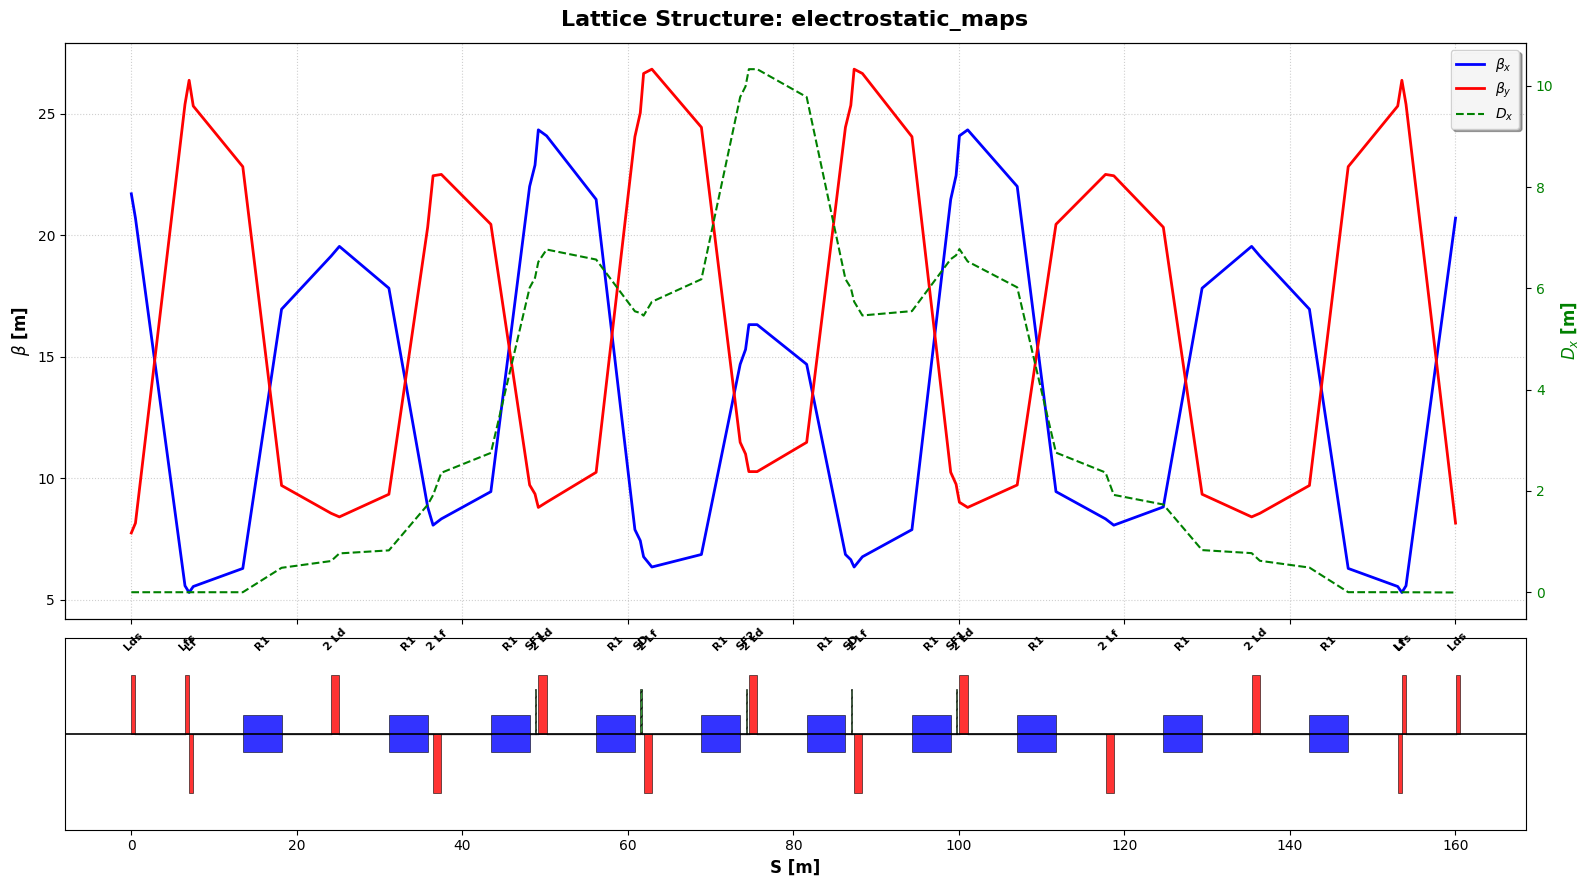

In [205]:
# 1. Рассчитываем физику (переменные Lds, Lf и т.д.)
vars_map = get_lattice_variables(lattice_name, src_path, global_inputs)

# 2. Собираем структуру из объектов
library, lattice_model = build_lattice_with_library(lattice_name, src_path, vars_map)

# 3. Загружаем бету и дисперсию из .dat
fill_optics_full(lattice_model, root_path, lattice_name)

# 4. РИСУЕМ КРАСОТУ
plot_lattice_analysis(lattice_model, title=f"Lattice Structure: {lattice_name}")